### Part 1 Data Acquisition 

Grab the first 5 pages of stories from hackernews. For each story, grab the following data:

Rank (the number of the story on hacker news)
Length of the title
Age, in hours (note, some stories are days or minutes old. You should be able to handle this)
Points (note, some stories don't have scores! Give them 0 points)
Number of comments (again, some stories have no comments. Mark them 0)

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

ranks = []
titleLengths = []
ageHours = []
points = []
commentsNum = []


#grab the first 5 pages from the hackernews

for page in range(1,6):
    url = f"https://news.ycombinator.com/news?p={page}"
    print(f"scraping page {page}: {url}")


    response = requests.get(url)
    # Check if request was successful
    if response.status_code != 200:
        print(f"Failed to fetch page {page}, status code: {response.status_code}")
        continue


    #parse HTML with BeautifulSOup 
    soup = BeautifulSoup(response.text, 'html.parser')


    # Find all story rows (each story is a <tr> with class="athing")
    stories = soup.find_all('tr', class_='athing')
    print(f"Found {len(stories)} stories on page {page}")
    
    for story in stories:

        #finding rank-- inside of tr (story) we have <td 
        #inside of each first td we have class= title with <span calss = rank...>
        rankTag = story.find('span', class_ ='rank')
        #ex: <span class="rank">39.</span>
        #just return rank as int for list 
        rank = int(rankTag.text.strip().replace('.','')) if rankTag else None
        #print(f"rank {rank}")

        #finding title length
        titleTag = story.find('span', class_='titleline')
        titleLink = titleTag.find('a') if titleTag else None
        title = titleLink.text.strip() if titleLink else 0
        #note: rank might change while writing 
        titleLength = len(title)
        print(f"Rank {rank} Title: '{title}' Length: {titleLength}")



        #finding Points
        #find next tr 
        subtextRow = story.find_next_sibling('tr')
        subtext = subtextRow.find('td', class_='subtext')
        scoreTag = subtext.find('span', class_='score') if subtext else None
        score = int(scoreTag.text.replace(' points','')) if scoreTag else 0

        #finding Age
        timeSincePostTag = subtext.find('span', class_='age') if subtext else None
        ageText = timeSincePostTag.text if timeSincePostTag else '0 hours ago'
        
        number = float(ageText.split()[0])
        if 'minute' in ageText:
            ageHr = round(number/60, 2)
        elif 'hour' in ageText:
            ageHr = number
        elif 'day' in ageText:
            ageHr = number * 24
        else:
            ageHr = 0.0
        print(f"Age of '{title}' : over {ageHr} hours ago")


        #finding comments
        commentLinks = subtext.find_all('a') if subtext else []
        #comment number if 
        commentText = commentLinks[-1].text if commentLinks else '0'
        if 'comment' in commentText:
            numComments = int(commentText.split()[0])
        else:
            numComments = 0
        print(f"number of comments for {title} = {numComments}")

        # Append to lists
        ranks.append(rank)
        titleLengths.append(titleLength)
        ageHours.append(ageHr)
        points.append(score)
        commentsNum.append(numComments)
    time.sleep(1)

# Save dataframe
df = pd.DataFrame({
    'Rank': ranks,
    'TitleLength': titleLengths,
    'AgeHours': ageHours,
    'Points': points,
    'Comments': commentsNum
})

df.to_csv('hnStories.csv', index=False)

    

scraping page 1: https://news.ycombinator.com/news?p=1
Found 30 stories on page 1
Rank 1 Title: 'Researchers develop ‘transparent paper’ as alternative to plastics' Length: 66
Age of 'Researchers develop ‘transparent paper’ as alternative to plastics' : over 2.0 hours ago
number of comments for Researchers develop ‘transparent paper’ as alternative to plastics = 32
Rank 2 Title: 'A year of funded FreeBSD development' Length: 36
Age of 'A year of funded FreeBSD development' : over 4.0 hours ago
number of comments for A year of funded FreeBSD development = 36
Rank 3 Title: 'Medieval Africans Had a Unique Process for Purifying Gold with Glass (2019)' Length: 75
Age of 'Medieval Africans Had a Unique Process for Purifying Gold with Glass (2019)' : over 1.0 hours ago
number of comments for Medieval Africans Had a Unique Process for Purifying Gold with Glass (2019) = 3
Rank 4 Title: 'How we decreased GitLab repo backup times from 48 hours to 41 minutes' Length: 69
Age of 'How we decreased Gi

### Part 2 Regression
We're interested in how to get a high-ranking story on Hackernews. Explore several possible least squares regressions to predict a story's rank based on the other variables (or combinations thereof). Include at least 3 different regressions. Compare/contrast them. Which is the most useful. Are there linear relationships between any of the variables? How about other relationships like inverse linear (1/x)?

In [3]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv('hnStories.csv')
print(df.head())


   Rank  TitleLength  AgeHours  Points  Comments
0     1           66       2.0     106        32
1     2           36       4.0     137        36
2     3           75       1.0      35         3
3     4           69       8.0     309       124
4     5           62      10.0     441       308


In [4]:
x1 = sm.add_constant(df['Points'])
y = df['Rank']

model1 = sm.OLS(y, x1).fit()
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.786
Date:                Fri, 06 Jun 2025   Prob (F-statistic):             0.0972
Time:                        18:06:25   Log-Likelihood:                -776.67
No. Observations:                 150   AIC:                             1557.
Df Residuals:                     148   BIC:                             1563.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.0700      4.413     16.103      0.0

Point allow proves to not be very correlated to rank alone and judging from the p value being huge it's shows that without more context Points look like a lot of noise.

In [5]:
x2 = sm.add_constant(df['Comments'])
y = df['Rank']

model1 = sm.OLS(y, x2).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     3.349
Date:                Fri, 06 Jun 2025   Prob (F-statistic):             0.0692
Time:                        18:06:26   Log-Likelihood:                -776.39
No. Observations:                 150   AIC:                             1557.
Df Residuals:                     148   BIC:                             1563.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.3221      4.195     17.001      0.0

In [6]:
x3 = sm.add_constant(df[['AgeHours']])
model2 = sm.OLS(y, x3).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     112.8
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           6.13e-20
Time:                        18:06:26   Log-Likelihood:                -735.58
No. Observations:                 150   AIC:                             1475.
Df Residuals:                     148   BIC:                             1481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.8079      4.299      9.259      0.0

So Far AgeHours does have the highest significance in determining rank and correlation with rank. But the correlation value is still relatively lackluster.

In [7]:
x4 = sm.add_constant(df[['TitleLength']])
model2 = sm.OLS(y, x4).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.286
Date:                Fri, 06 Jun 2025   Prob (F-statistic):              0.259
Time:                        18:06:26   Log-Likelihood:                -777.42
No. Observations:                 150   AIC:                             1559.
Df Residuals:                     148   BIC:                             1565.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          86.0476      9.954      8.644      

In [8]:
x5 = sm.add_constant(df[['Points', 'Comments']])
model2 = sm.OLS(y, x5).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.670
Date:                Fri, 06 Jun 2025   Prob (F-statistic):              0.192
Time:                        18:06:26   Log-Likelihood:                -776.38
No. Observations:                 150   AIC:                             1559.
Df Residuals:                     147   BIC:                             1568.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.1696      4.422     16.094      0.0

In [9]:
x6 = sm.add_constant(df[['Points', 'Comments', 'AgeHours']])
model3 = sm.OLS(y, x6).fit()
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     42.46
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           8.68e-20
Time:                        18:06:26   Log-Likelihood:                -731.02
No. Observations:                 150   AIC:                             1470.
Df Residuals:                     146   BIC:                             1482.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.5431      4.241      9.795      0.0

When including multiple variables we tend to have a higher correlation, which is still very low. When comparing the variables effect on rank, 'Points' proves to have the best effect on rank by reducing it slightly, the pValue show that when taking 'Points','Comments', and 'AgeHours' into consideration at the same time that they are not in fact just noise (well sometimes it does, I ran all my code the next day and all the values changed resulting in pvalues like this one where comments and points are now looking like noise). With a F-statistic of 42.46 and all signficant p values, the model suggests that using these variables together is starting to allow us to predict accurately.

In [10]:
df['InvPoints'] = 1 / (df['Points'] + 1)

X_inv = sm.add_constant(df['InvPoints'])
model_inv = sm.OLS(y, X_inv).fit()
print(model_inv.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.7651
Date:                Fri, 06 Jun 2025   Prob (F-statistic):              0.383
Time:                        18:06:26   Log-Likelihood:                -777.68
No. Observations:                 150   AIC:                             1559.
Df Residuals:                     148   BIC:                             1565.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.7475      3.826     20.060      0.0

Although the -34.5979 coef represents a large improvement for rank, the data tells us this is meaningless, the correlation value is next to nothing and the pValue is far from giving us confidence in this result.

In [11]:
x6 = sm.add_constant(df[['Points', 'Comments', 'AgeHours','TitleLength']])
model3 = sm.OLS(y, x6).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     33.08
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           1.37e-19
Time:                        18:06:26   Log-Likelihood:                -729.44
No. Observations:                 150   AIC:                             1469.
Df Residuals:                     145   BIC:                             1484.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          27.4140      9.060      3.026      

This is the best model seen, this regression represents about 47.7% of the variance. The F-statstic is of 33.08 is large and some of our pValues are significant meaning that atleast one of our variables is an accurate predictor for rank.  It's annoying -- I wanted to make sure I was doing a good job from the day before and I accidently ran all my code so some of my values might be alittle different because even the csv was rewritten when I ran it from the top today.

### Part 3 Classification
As smart people, we know that your rank on HN doesn't matter, as long as you're on the front page. Use logistic regression to attempt to classify whether or not an article will be on the front page, given the other (non-rank) variables. Note, you'll need to transform the rank variable into an indicator variable (1 for front page, 0 for not), for example.

Include plots showing your regression (for the functions of 1 or 2 variables). What do your regressions tell you about making the front page?

In [12]:
df['FrontPage'] = df['Rank'].apply(lambda x: 1 if x <= 30 else 0)

print(df['FrontPage'].value_counts())


FrontPage
0    120
1     30
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

#features and target
X = df[['Points', 'Comments', 'AgeHours']]
y = df['FrontPage']

#train/test split (80% train, 20% test)
XTrain, XTest, YTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=42)

#fit logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(XTrain, YTrain)

#predict
yPred = clf.predict(XTest)

#evaluate
print(classification_report(yTest, yPred))
print(confusion_matrix(yTest, yPred))


              precision    recall  f1-score   support

           0       0.82      0.96      0.88        24
           1       0.50      0.17      0.25         6

    accuracy                           0.80        30
   macro avg       0.66      0.56      0.57        30
weighted avg       0.76      0.80      0.76        30

[[23  1]
 [ 5  1]]


In Part 3, I used logistic regression to classify whether a story would appear on the front page (Rank ≤ 30), using Points, Comments, and AgeHours as predictors. The model achieved an overall accuracy of 80%, with good precision (82%) and recall (96%) for predicting Not Front Page stories. Predicting Front Page stories was far worse, with precision of 60% and recall of 17%, likely due to the smaller number of Front Page examples and the inherent noise in HackerNews rankings.

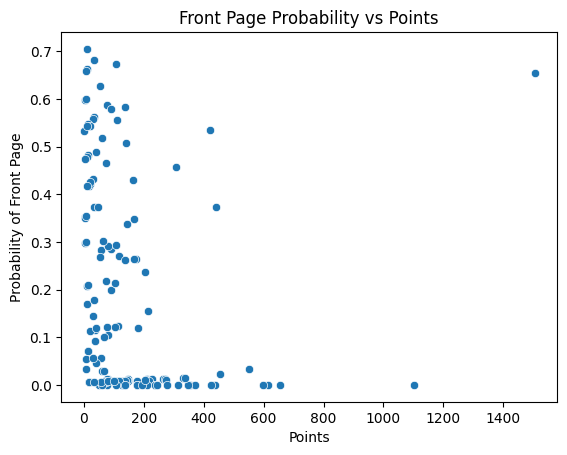

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities on whole dataset
df['FrontProb'] = clf.predict_proba(X)[:,1]

# Plot Points vs FrontPage probability
sns.scatterplot(x='Points', y='FrontProb', data=df)
plt.xlabel('Points')
plt.ylabel('Probability of Front Page')
plt.title('Front Page Probability vs Points')
plt.show()


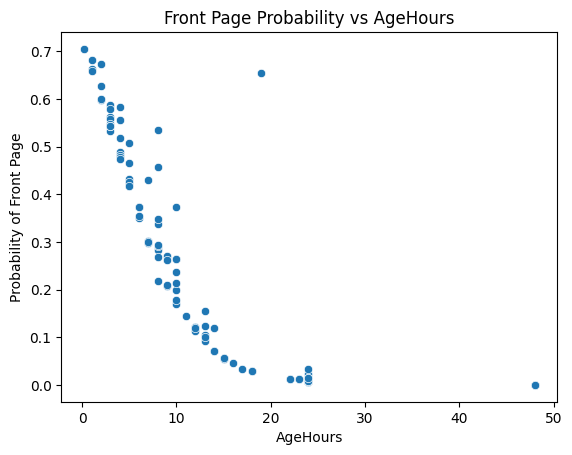

In [15]:
sns.scatterplot(x='AgeHours', y='FrontProb', data=df)
plt.xlabel('AgeHours')
plt.ylabel('Probability of Front Page')
plt.title('Front Page Probability vs AgeHours')
plt.show()


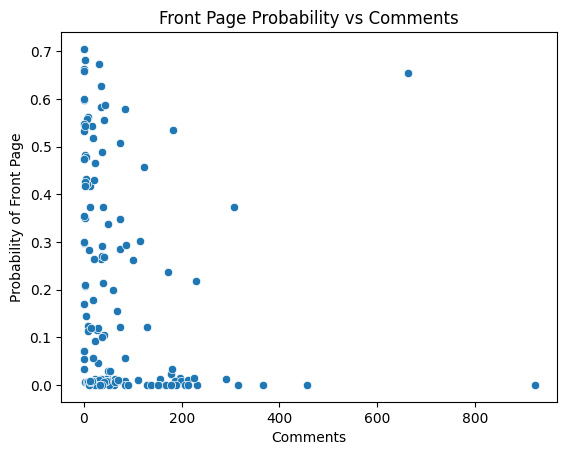

In [16]:
sns.scatterplot(x='Comments', y='FrontProb', data=df)
plt.xlabel('Comments')
plt.ylabel('Probability of Front Page')
plt.title('Front Page Probability vs Comments')
plt.show()


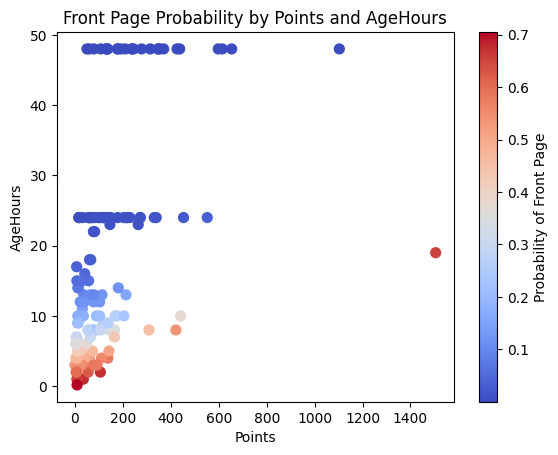

In [19]:


plt.scatter(df['Points'], df['AgeHours'], c=df['FrontProb'], cmap='coolwarm', s=50)
plt.xlabel('Points')
plt.ylabel('AgeHours')
plt.title('Front Page Probability by Points and AgeHours')
plt.colorbar(label='Probability of Front Page')
plt.show()


Continuing Part 3

The probability vs AgeHours plot shows a clear negative relationship. The stories with lower hours have a much greater probability of being on the Front Page. This confirms that AgeHours is a strong driver of Front Page appearance. Comments and Points also contribute to the model, but the AgeHours feature impact is the most visible within the different plots.
